In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv("car_price_prediction_.csv")
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car ID               2500 non-null   int64  
 1   Year                 2500 non-null   int64  
 2   Engine Size          2500 non-null   float64
 3   Mileage              2500 non-null   int64  
 4   Price                2500 non-null   float64
 5   Brand_BMW            2500 non-null   bool   
 6   Brand_Ford           2500 non-null   bool   
 7   Brand_Honda          2500 non-null   bool   
 8   Brand_Mercedes       2500 non-null   bool   
 9   Brand_Tesla          2500 non-null   bool   
 10  Brand_Toyota         2500 non-null   bool   
 11  Fuel Type_Electric   2500 non-null   bool   
 12  Fuel Type_Hybrid     2500 non-null   bool   
 13  Fuel Type_Petrol     2500 non-null   bool   
 14  Transmission_Manual  2500 non-null   bool   
 15  Condition_New        2500 non-null   b

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [2]:
df.isnull().sum()
df.drop(['Car ID'], axis=1, inplace=True)
df.head()

,Year,Engine Size,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,2016,2.3,114832,26613.92,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
1,2018,4.4,143190,14679.61,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2013,4.5,181601,44402.61,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2011,4.1,68682,86374.33,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
4,2009,2.6,223009,73577.10,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [3]:
print(X.head())
print(y.head())
print(X_train.shape)
print(X_test.shape)

   Car ID  Year  Engine Size  Mileage  Brand_BMW  Brand_Ford  Brand_Honda  \
0       1  2016          2.3   114832      False       False        False   
1       2  2018          4.4   143190       True       False        False   
2       3  2013          4.5   181601      False       False        False   
3       4  2011          4.1    68682      False       False        False   
4       5  2009          2.6   223009      False        True        False   

   Brand_Mercedes  Brand_Tesla  Brand_Toyota  ...  Model_Model S  \
0           False         True         False  ...          False   
1           False        False         False  ...          False   
2           False        False         False  ...          False   
3           False         True         False  ...          False   
4           False        False         False  ...          False   

   Model_Model X  Model_Model Y  Model_Mustang  Model_Prius  Model_Q5  \
0           True          False          False        F

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

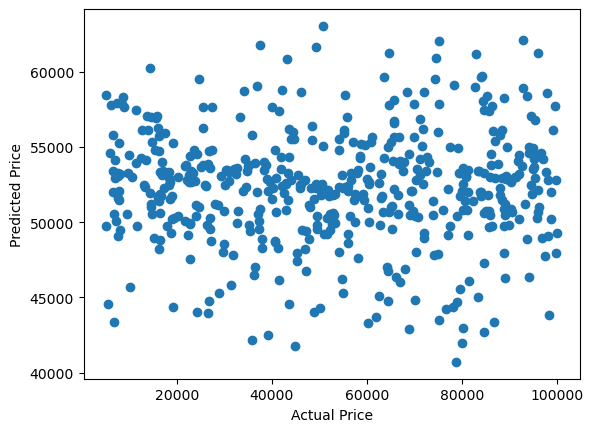

In [5]:
y_pred = model.predict(X_test)
y_pred[:5]

r2_score(y_test, y_pred)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()